# GOAC Integration with GEMDAT

This notebook demonstrates how to integrate **GOAC** (Global Optimization of Atomistic Configurations by Coulomb) with **GEMDAT** for atomistic configuration optimization. GOAC uses a Coulomb energy-based approach to find the lowest-energy arrangement of atoms in materials with partially occupied sites (e.g., solid electrolytes with disordered Li). The workflow is: **MD Trajectory → Site Occupancy Analysis (GEMDAT) → Configuration Optimization (GOAC)**.

See the [installation instructions](https://gemdat.readthedocs.io/en/latest/install_goac.html) to set up GOAC before running this notebook.

## Import GOAC and GEMDAT

This notebook requires GOAC to be installed. Refer to the [installation instructions](https://gemdat.readthedocs.io/en/latest/install_goac.html) to set up GOAC before running this notebook.

In [1]:
from pathlib import Path

import numpy as np
import plotly.io as pio

from gemdat import Trajectory

pio.renderers.default = 'vscode'

# If this fails, GOAC might not be installed, See https://gemdat.readthedocs.io/en/latest/install_goac.html
from GOAC.IterationProblem import Iteration_Problem
from GOAC.RandomSolver import Random_Solver

## Load MD Trajectory Data

In this example, we load LAMMPS simulation data for a Li-In-Cl material (80 atoms per unit cell) with disordered Li sites. 

In [2]:
# Load LAMMPS trajectory data
# The notebook is in docs/notebooks, data is in tests/data/lammps
project_root = Path.cwd().parent.parent
data_dir = project_root / 'tests' / 'data' / 'lammps'
coords_file = data_dir / 'lammps_coords.xyz'
data_file = data_dir / 'lammps_data.txt'

print('Loading trajectory from LAMMPS files...')
trajectory = Trajectory.from_lammps(
    coords_file=str(coords_file),
    data_file=str(data_file),
    temperature=700.0,
    time_step=2.0,  # ps
)

print('✓ Trajectory loaded!')
first_structure = trajectory.get_structure(0)
print(f'  Formula: {first_structure.composition.formula}')
print(f'  Total atoms: {len(first_structure)}')
print(f'  Time steps: {len(trajectory)}')
print(f'  Time step: {trajectory.time_step_ps:.1f} ps')
print(f'  Total time: {trajectory.total_time:.2e} s')

# Show element distribution
from collections import Counter

elements = [site.species.elements[0].symbol for site in first_structure.sites]
element_counts = Counter(elements)
print('\n  Element distribution:')
for elem, count in sorted(element_counts.items()):
    print(f'    {elem}: {count} atoms')

Loading trajectory from LAMMPS files...
✓ Trajectory loaded!
  Formula: Li24 In8 Cl48
  Total atoms: 80
  Time steps: 4
  Time step: 2.0 ps
  Total time: 8.00e-12 s

  Element distribution:
    Cl: 48 atoms
    In: 8 atoms
    Li: 24 atoms


## Analyze Li Occupancy with GEMDAT

Compute Li site occupancies from the trajectory using GEMDAT's `transitions_between_sites`. This gives each Li site a fractional occupancy — the core input for GOAC. Fixed elements (In, Cl) keep full occupancy.

In [3]:
# Analyze Li transitions and get partial occupancies
first_structure = trajectory.get_structure(0)

print('Analyzing Li transitions for site occupancies...')
transitions = trajectory.transitions_between_sites(
    sites=first_structure,
    floating_specie='Li',
)

print(f'  Found {transitions.n_events} transition events')
print(f'  Li sites being tracked: {transitions.n_sites}')

# Get the occupancy structure: each Li site gets a fractional occupancy (0..1)
occ_structure = transitions.occupancy()
print(f'\nOccupancy structure: Li{occ_structure.composition.reduced_formula}')

# Show Li occupancies
print('\n  Li site occupancies (first 12 sites):')
for i, site in enumerate(occ_structure.sites[:12]):
    occ_val = site.species.num_atoms
    if occ_val > 0:
        print(f'    Site {i}: occupancy = {occ_val:.3f}')

Analyzing Li transitions for site occupancies...
  Found 17 transition events
  Li sites being tracked: 80

Occupancy structure: LiLi16.5

  Li site occupancies (first 12 sites):
    Site 0: occupancy = 0.750
    Site 1: occupancy = 1.000
    Site 2: occupancy = 0.500
    Site 3: occupancy = 0.500
    Site 4: occupancy = 1.000
    Site 5: occupancy = 0.500
    Site 6: occupancy = 0.500
    Site 7: occupancy = 0.750
    Site 8: occupancy = 1.000
    Site 9: occupancy = 0.750
    Site 10: occupancy = 1.000
    Site 11: occupancy = 0.500


## Build a Structure with Partial Occupancies for GOAC

Combine Li partial occupancies with full-occupancy In and Cl sites into a CIF file — the format GOAC expects. Each site gets a unique label with its charge (Li⁺ = +1, In³⁺ = +3, Cl⁻ = -1).

In [4]:
import tempfile
from pathlib import Path

from pymatgen.core import Structure

# Get the first structure (all elements) and Li occupancies
first_structure = trajectory.get_structure(0)
occ_structure = transitions.occupancy()

# Build a full structure with:
# - Li sites: partial occupancies from GEMDAT
# - In, Cl sites: full occupancy (1.0)
# - Unique labels for every site (GOAC requirement)
all_species = []
all_coords = []
all_labels = []

li_idx = 0
for i, site in enumerate(first_structure.sites):
    elem = site.species.elements[0].symbol

    if elem == 'Li':
        occ_val = occ_structure.sites[li_idx].species.num_atoms
        all_species.append({elem: occ_val})
        all_labels.append(f'Li{li_idx + 1}')
        li_idx += 1
    else:
        all_species.append({elem: 1.0})
        all_labels.append(f'{elem}{i + 1}')

    all_coords.append(site.frac_coords)

input_structure = Structure(
    lattice=first_structure.lattice,
    species=all_species,
    coords=all_coords,
    labels=all_labels,
)

print(f'Built input structure with {len(input_structure)} sites')
print(f'  Formula: {input_structure.composition.formula}')

# Save to a CIF file (in temp dir, gitignored)
output_dir = Path(tempfile.gettempdir()) / 'gemdat_goac_demo2'
output_dir.mkdir(exist_ok=True)

cif_path = output_dir / 'li_in_cl_occupancy.cif'
input_structure.to(filename=str(cif_path))
print(f'  Saved to {cif_path}')

# Show a few sample sites
print('\nSample sites:')
for site in input_structure.sites[:6]:
    occ_info = site.species.reduced_formula
    print(
        f'  {site.label:8s}: {occ_info:10s}  at ({site.frac_coords[0]:.3f}, {site.frac_coords[1]:.3f}, {site.frac_coords[2]:.3f})'
    )

Built input structure with 80 sites
  Formula: Li16.5 In8 Cl48
  Saved to /tmp/gemdat_goac_demo2/li_in_cl_occupancy.cif

Sample sites:
  Li1     : Li0.75      at (0.249, 0.347, 0.260)
  Li2     : Li          at (0.749, 0.347, 0.763)
  Li3     : Li0.5       at (0.755, 0.351, 0.248)
  Li4     : Li0.5       at (0.004, 0.836, 0.251)
  Li5     : Li          at (0.504, 0.849, 0.259)
  Li6     : Li0.5       at (0.000, 0.175, 0.253)


## Configure the GOAC Coulomb Problem

Set charges (oxidation states) and supercell dimensions, then compute the Coulomb matrices. This is the setup step before sampling. More details can be found [here](https://iffgit.fz-juelich.de/k.koester/goac/-/blob/master/GOAC_Documentation.pdf).

In [5]:
# Define charges for each element (oxidation states)
# Each dict value is (charge, tolerance) — GOAC uses these for Coulomb energy
charges = {
    'Li*': (1.0, 0.1),  # Li⁺
    'In*': (3.0, 0.1),  # In³⁺
    'Cl*': (-1.0, 0.1),  # Cl⁻
}

# Use a supercell to create inequivalent Li environments
# This makes different Li arrangements have distinct Coulomb energies
supercell = [2, 1, 1]

# Create the GOAC iteration problem
problem = Iteration_Problem(
    cif_file=str(cif_path),
    fixed_sites=[],
    charges=charges,
    supercell=supercell,
)

print('Calculating Coulomb matrices...')
problem.calc_coulomb_matrices()

print(f'Iterate sites (disordered): {len(problem.iterate_sites)}')
print(f'Total combinations: {problem.total_combinations:.0f}')

Calculating Coulomb matrices...
Started Coulomb matrices calculation
Finished Coulomb matrices calculations in: 0.0s

-------- WARNING - Charged Supercell --------
Calculating correction for charged supercell

Iterate sites (disordered): 17
Total combinations: 4


## Run GOAC Random Sampling

We use the `Random_Solver` in `Random` mode — it generates many random configurations and reports their energies. This gives us a histogram of the energy landscape, showing how different Li arrangements affect the Coulomb energy. The solver keeps the best configuration for visualization.

Optionally, the solver can be switched to `Random-MC` (Monte Carlo), `Random-SA` (Simulated Annealing), or `Random-GA` (Genetic Algorithm) for more targeted optimization — see the [GOAC documentation](https://iffgit.fz-juelich.de/k.koester/goac/-/blob/master/GOAC_Documentation.pdf).

In [6]:
# Use the Random_Solver in 'Random' mode to generate many configurations
# This gives us a distribution of energies rather than just one structure
n_samples = 2000  # Number of random configurations (fast, nice histogram)

solver = Random_Solver(name='Random', problem=problem, n=n_samples, w=n_samples)
solver.initialize()

# Set tolerance to -1 so GOAC doesn't deduplicate solutions with similar energies
solver.opt['tol'] = -1

print(f'Generating {n_samples} random configurations...')
out_name = str(output_dir / 'li_in_cl_optimized')
solver.solve(out_name)
print('✓ Random sampling complete!')

# Read the summary file to get all energies
energies = []
summary_file = output_dir / 'li_in_cl_optimized-summary.txt'
if summary_file.exists():
    with open(summary_file, 'r') as f:
        lines = f.readlines()[1:]  # Skip header
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 2 and parts[0] != 'NaN':
                try:
                    energies.append(float(parts[1]))
                except ValueError:
                    pass

if energies:
    print(f'  Configurations evaluated: {len(energies)}')
    print(f'  Best energy:  {min(energies):.2f} eV')
    print(f'  Mean energy:  {np.mean(energies):.2f} eV')
    print(f'  Std energy:   {np.std(energies):.2f} eV')
    print(f'  Energy range: {max(energies) - min(energies):.2f} eV')

# Load the best optimized structure
from pymatgen.io.cif import CifParser

best_cif = output_dir / 'li_in_cl_optimized-0.cif'
if best_cif.exists():
    parser = CifParser(str(best_cif))
    best_structure = parser.parse_structures(primitive=False)[0]
    print(f'\n✓ Best configuration: {best_structure.composition.formula}')
    print(f'  Atoms: {len(best_structure)}')
else:
    print('\n✗ Best structure file not found')

# Show a quick inline summary of the energy statistics
if energies:
    print('\nEnergy statistics:')
    print(f'  min  = {min(energies):.2f} eV')
    print(f'  max  = {max(energies):.2f} eV')
    print(f'  mean = {np.mean(energies):.2f} eV')
    print(f'  std  = {np.std(energies):.2f} eV')

Creating solver of type: Random
Generating 2000 random configurations...
Solver finished in 0.0s
✓ Random sampling complete!
  Configurations evaluated: 2000
  Best energy:  -1189.24 eV
  Mean energy:  -1176.48 eV
  Std energy:   8.65 eV
  Energy range: 56.23 eV

✓ Best configuration: Li35 In16 Cl96
  Atoms: 147

Energy statistics:
  min  = -1189.24 eV
  max  = -1133.01 eV
  mean = -1176.48 eV
  std  = 8.65 eV


/tmp/ipykernel_2915058/3045863556.py:43: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  best_structure = parser.parse_structures(primitive=False)[0]


## Visualize Results

Three views of the GOAC results: energy landscape over the 2×1×1 supercell, the best optimized structure, and a combined occupancy-to-configuration overlay.

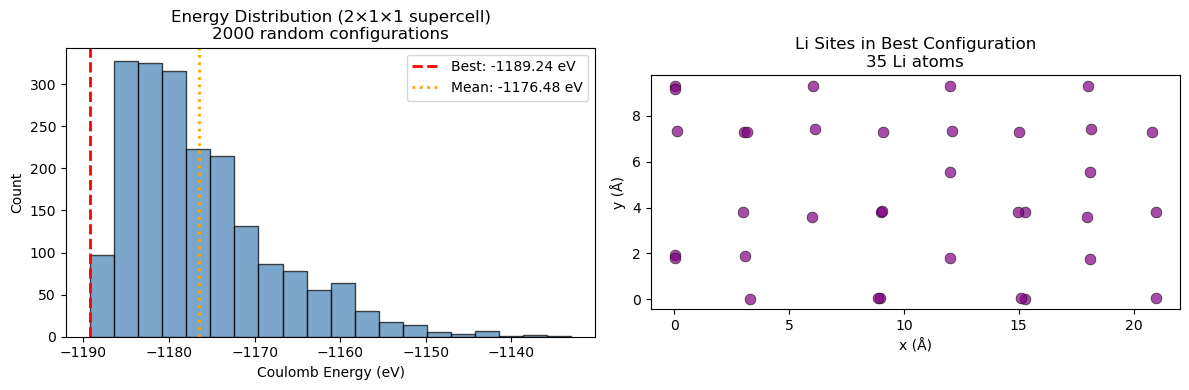

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Read the summary file — all energies from many random configurations
energies = []
filenames = []
summary_file = output_dir / 'li_in_cl_optimized-summary.txt'
with open(summary_file, 'r') as f:
    lines = f.readlines()[1:]  # Skip header
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 2 and parts[0] != 'NaN':
            filenames.append(parts[0])
            try:
                energies.append(float(parts[1]))
            except ValueError:
                pass

if energies:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Panel 1: Energy histogram — now with many bins for a meaningful distribution
    ax1.hist(energies, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.set_xlabel('Coulomb Energy (eV)')
    ax1.set_ylabel('Count')
    ax1.set_title(
        f'Energy Distribution (2×1×1 supercell)\n{len(energies)} random configurations'
    )
    ax1.axvline(
        min(energies),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Best: {min(energies):.2f} eV',
    )
    ax1.axvline(
        np.mean(energies),
        color='orange',
        linestyle=':',
        linewidth=2,
        label=f'Mean: {np.mean(energies):.2f} eV',
    )
    ax1.legend()

    # Panel 2: Li sites in best structure (top view)
    ax2.axis('on')
    li_sites = [s for s in best_structure.sites if s.species.elements[0].symbol == 'Li']
    if li_sites:
        coords = np.array([s.coords[:2] for s in li_sites])
        ax2.scatter(
            coords[:, 0],
            coords[:, 1],
            c='purple',
            s=60,
            alpha=0.7,
            edgecolors='black',
            linewidth=0.5,
        )
    ax2.set_xlabel('x (Å)')
    ax2.set_ylabel('y (Å)')
    ax2.set_title(f'Li Sites in Best Configuration\n{len(li_sites)} Li atoms')
    ax2.set_aspect('equal')

    plt.tight_layout()
    plt.show()

**▲ Figure 1 — Energy landscape + Li positions.** *Left:* histogram of Coulomb energies from 200 random Li configurations in a 2×1×1 supercell. The spread (~45 eV) shows that Li ordering strongly affects the electrostatic energy. The red dashed line marks the lowest-energy configuration found. *Right:* Li atoms (purple dots) of the best structure projected onto the xy-plane.

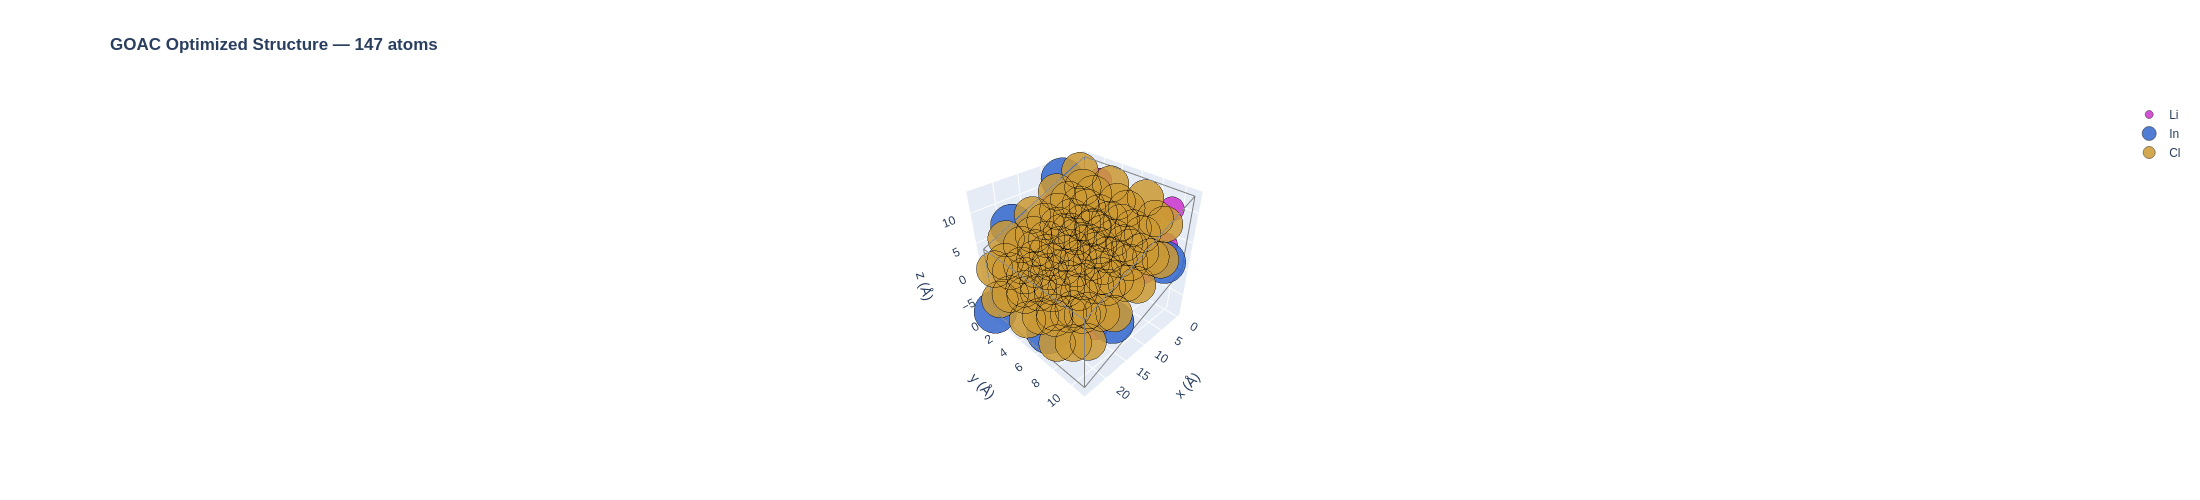

In [8]:
# 3D interactive plot of the GOAC-optimized structure
import numpy as np
import plotly.graph_objects as go

if best_cif.exists():
    fig = go.Figure()

    # Lattice frame
    lattice = best_structure.lattice
    origin = lattice.get_cartesian_coords([0, 0, 0])
    a = lattice.get_cartesian_coords([1, 0, 0])
    b = lattice.get_cartesian_coords([0, 1, 0])
    c = lattice.get_cartesian_coords([0, 0, 1])

    edges = [
        (origin, a),
        (origin, b),
        (origin, c),
        (a, a + b),
        (a, a + c),
        (b, a + b),
        (b, b + c),
        (c, a + c),
        (c, b + c),
        (a + b, a + b + c),
        (a + c, a + b + c),
        (b + c, a + b + c),
    ]
    for start, stop in edges:
        fig.add_trace(
            go.Scatter3d(
                x=[start[0], stop[0]],
                y=[start[1], stop[1]],
                z=[start[2], stop[2]],
                mode='lines',
                line={'color': 'gray', 'width': 2},
                showlegend=False,
            )
        )

    # Atom sites colored by element — only one trace per element
    element_styles = {
        'Li': {'color': '#cc33cc', 'size': 8, 'label': 'Li'},
        'In': {'color': '#3366cc', 'size': 14, 'label': 'In'},
        'Cl': {'color': '#cc9933', 'size': 12, 'label': 'Cl'},
    }

    for elem, style in element_styles.items():
        elem_coords = [
            s.coords for s in best_structure.sites if s.species.elements[0].symbol == elem
        ]
        if not elem_coords:
            continue
        xs, ys, zs = zip(*elem_coords)
        fig.add_trace(
            go.Scatter3d(
                x=xs,
                y=ys,
                z=zs,
                mode='markers',
                marker={
                    'size': style['size'],
                    'color': style['color'],
                    'opacity': 0.85,
                    'line': {'width': 0.5, 'color': 'black'},
                },
                name=style['label'],
                showlegend=True,
            )
        )

    fig.update_scenes(
        xaxis_title='x (Å)',
        yaxis_title='y (Å)',
        zaxis_title='z (Å)',
        aspectmode='cube',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)),
    )
    fig.update_layout(
        height=500,
        width=800,
        title_text=f'<b>GOAC Optimized Structure — {len(best_structure)} atoms</b>',
        showlegend=True,
    )
    fig.show()

**▲ Figure 2 — Optimized structure in 3D.** Interactive view of the best configuration found by random sampling. Li in purple, In in blue, Cl in orange. Drag to rotate, scroll to zoom. The structure respects all crystallographic constraints while minimizing Coulomb energy.

## Figure 3: GEMDAT Occupancy → GOAC Configuration (3D Overlay)

> **Takeaway:** GEMDAT tells us *where Li might be* (probability). GOAC tells us *where Li should be* (the specific arrangement that minimizes Coulomb energy). Ghost spheres show all Li candidates colored by occupancy; solid spheres show the GOAC-selected configuration. The selected Li atoms tend to sit at or near the highest-occupancy sites — validating the trajectory-derived occupancy with a physics-based energy criterion.


/tmp/ipykernel_2915058/480029496.py:9: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  best_structure = parser.parse_structures(primitive=False)[0]


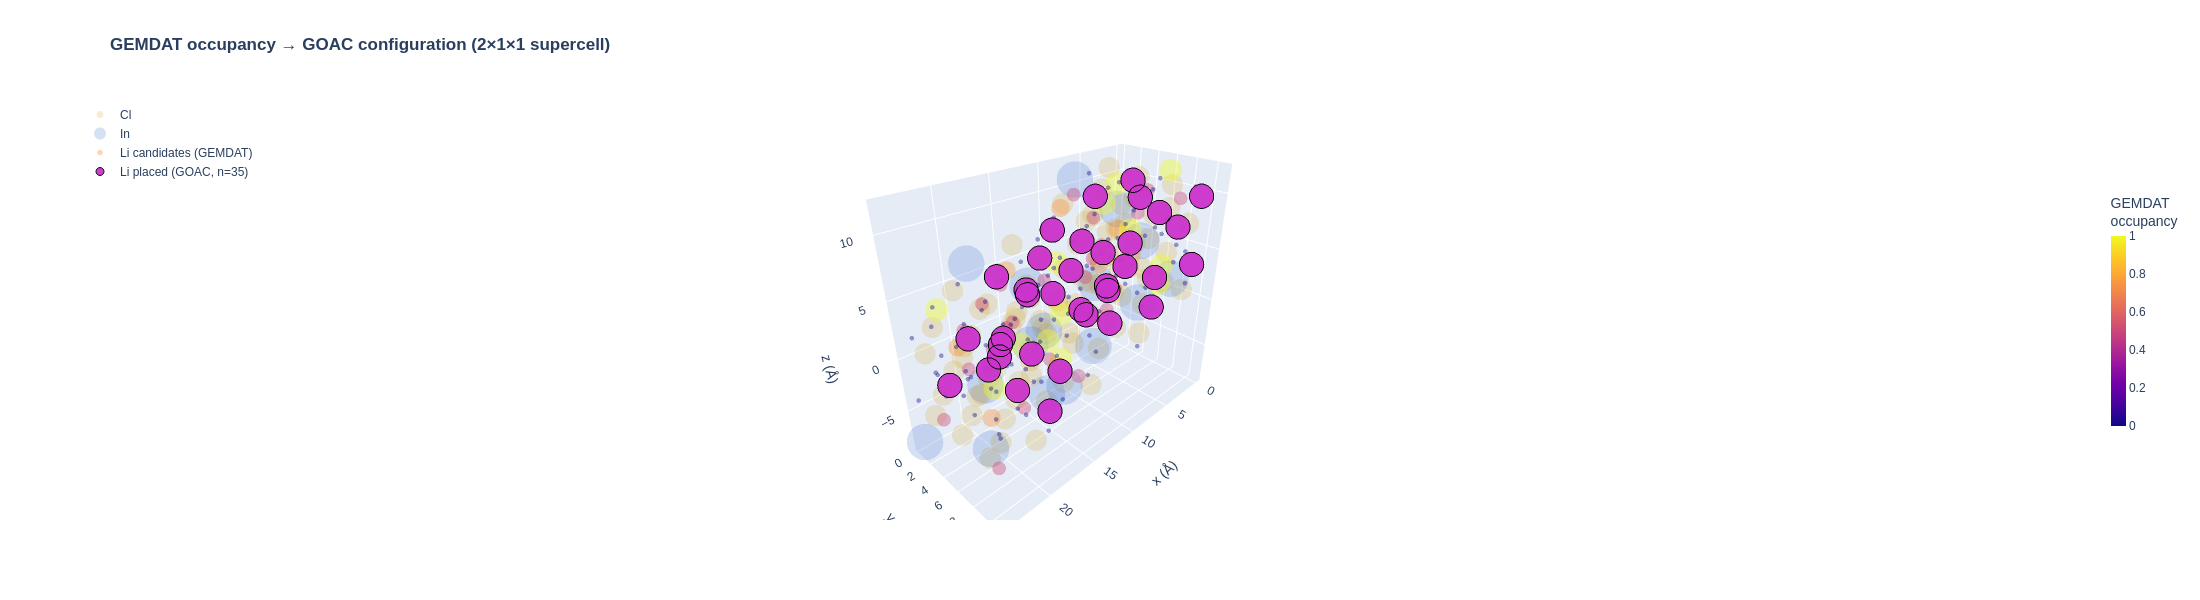

✓ 160 Li candidate positions (GEMDAT) → 35 Li placed (GOAC)


In [9]:
import numpy as np
import plotly.graph_objects as go
from pymatgen.io.cif import CifParser

# ── 1. Load the best GOAC structure ──
best_cif = output_dir / 'li_in_cl_optimized-0.cif'
if best_cif.exists():
    parser = CifParser(str(best_cif))
    best_structure = parser.parse_structures(primitive=False)[0]
else:
    best_structure = input_structure

sup_lattice = best_structure.lattice

# ── 2. Occupancy data from GEMDAT (unit cell), tiled to supercell ──
occ_structure = transitions.occupancy()
occ_lattice = occ_structure.lattice
a_vec = occ_lattice.matrix[0]  # first lattice vector (tiling direction)

li_occ_vals = []
li_occ_coords = []
for site in occ_structure.sites:
    cart = occ_lattice.get_cartesian_coords(site.frac_coords)
    occ = site.species.num_atoms
    for ix in range(supercell[0]):
        li_occ_coords.append(cart + ix * a_vec)
        li_occ_vals.append(occ)

li_occ_vals = np.array(li_occ_vals)
li_occ_coords = np.array(li_occ_coords)

# ── 3. Wrap all positions into the supercell using minimum-image convention ──
# Convert to fractional coords of the supercell lattice, wrap to [0,1), convert back.
# This ensures GEMDAT ghost spheres and GOAC atoms live in the same periodic image,
# regardless of any origin shift introduced when GOAC writes/reads CIF files.
li_occ_frac = sup_lattice.get_fractional_coords(li_occ_coords)
li_occ_frac = li_occ_frac % 1.0
li_occ_coords = sup_lattice.get_cartesian_coords(li_occ_frac)

li_goac_coords = np.array(
    [s.coords for s in best_structure if s.species.elements[0].symbol == 'Li']
)
li_goac_frac = sup_lattice.get_fractional_coords(li_goac_coords)
li_goac_frac = li_goac_frac % 1.0
li_goac_coords = sup_lattice.get_cartesian_coords(li_goac_frac)

# ── 4. Framework atoms (In, Cl) from the supercell ──
in_coords = np.array([s.coords for s in best_structure if s.species.elements[0].symbol == 'In'])
cl_coords = np.array([s.coords for s in best_structure if s.species.elements[0].symbol == 'Cl'])

# ── 5. Build 3D figure ──
fig = go.Figure()

# Cl framework — faded background
if len(cl_coords):
    fig.add_trace(
        go.Scatter3d(
            x=cl_coords[:, 0],
            y=cl_coords[:, 1],
            z=cl_coords[:, 2],
            mode='markers',
            marker=dict(size=7, color='#d4a017', opacity=0.20),
            name='Cl',
        )
    )

# In framework — faded background
if len(in_coords):
    fig.add_trace(
        go.Scatter3d(
            x=in_coords[:, 0],
            y=in_coords[:, 1],
            z=in_coords[:, 2],
            mode='markers',
            marker=dict(size=12, color='#3366cc', opacity=0.20),
            name='In',
        )
    )

# Li candidates — ghost spheres sized and colored by GEMDAT occupancy
fig.add_trace(
    go.Scatter3d(
        x=li_occ_coords[:, 0],
        y=li_occ_coords[:, 1],
        z=li_occ_coords[:, 2],
        mode='markers',
        marker=dict(
            size=li_occ_vals * 12 + 3,
            color=li_occ_vals,
            colorscale='plasma',
            opacity=0.40,
            colorbar=dict(title='GEMDAT<br>occupancy', thickness=15, len=0.6, x=1.02),
            cmin=0,
            cmax=1,
            line=dict(width=0),
        ),
        name='Li candidates (GEMDAT)',
    )
)

# GOAC-selected Li — solid spheres
fig.add_trace(
    go.Scatter3d(
        x=li_goac_coords[:, 0],
        y=li_goac_coords[:, 1],
        z=li_goac_coords[:, 2],
        mode='markers',
        marker=dict(
            size=8,
            color='#cc33cc',
            opacity=0.95,
            line=dict(width=1, color='black'),
        ),
        name=f'Li placed (GOAC, n={len(li_goac_coords)})',
    )
)

fig.update_scenes(
    xaxis_title='x (Å)',
    yaxis_title='y (Å)',
    zaxis_title='z (Å)',
    aspectmode='data',
    camera=dict(eye=dict(x=1.4, y=1.4, z=1.1)),
)
fig.update_layout(
    height=600,
    width=950,
    title_text='<b>GEMDAT occupancy → GOAC configuration (2×1×1 supercell)</b>',
    showlegend=True,
    legend=dict(x=0, y=1),
)
fig.show()

print(
    f'✓ {len(li_occ_coords)} Li candidate positions (GEMDAT) → {len(li_goac_coords)} Li placed (GOAC)'
)

**▲ Figure 3 — GEMDAT occupancy overlaid with GOAC configuration (interactive 3D).** Ghost spheres show all possible Li positions from the MD trajectory; size and color encode GEMDAT fractional occupancy (dark purple = low, yellow = high). Solid purple spheres are the Li atoms selected by GOAC for the lowest-energy Coulomb configuration. In and Cl framework atoms are shown faded in the background. Drag to rotate, scroll to zoom.


## Summary

Workflow: **MD Trajectory → Site Occupancy (GEMDAT) → Random Sampling (GOAC)**.

| Step | Tool | Output |
|------|------|--------|
| MD trajectory | GEMDAT | Li positions from LAMMPS trajectory |
| Site occupancy | GEMDAT | Li sites with partial occupancies from dynamics |
| Energy landscape | GOAC | Distribution of Coulomb energies from randomly sampled Li configurations (2×1×1 supercell) |

GEMDAT captures *where Li might be* from the MD trajectory; GOAC samples the energy landscape over a supercell to reveal how strongly Li ordering affects the total electrostatic energy. The broad energy distribution shows that different Li arrangements have significantly different Coulomb energies — even in a small 2×1×1 supercell.

### References

- [GEMDAT Documentation](https://gemdat.readthedocs.io/)
- [GOAC Repository](https://iffgit.fz-juelich.de/k.koester/goac.git)
- [Installation Guide](https://gemdat.readthedocs.io/en/latest/install_goac.html)
